# Агрегация данных

## Статистика по количеству клиентов в городах 📊 

Цель: посчитать количество клиентов в каждом городе, чтобы определить самые крупные и провести в них региональные акции

<div class="alert alert-block alert-info">

<pre>
<b>SELECT</b> 
    customer_city,
    COUNT(customer_id) <b>AS</b> customers_count
<b>FROM</b> 
    customers
<b>GROUP BY</b> customer_city
<b>ORDER BY</b> customers_count DESC;
</pre>

</div>

Вывод: в топ-5 городов по количеству клиентов вошли Красноярск, Воронеж, Самара, Нижний Новгород и Ижевск.

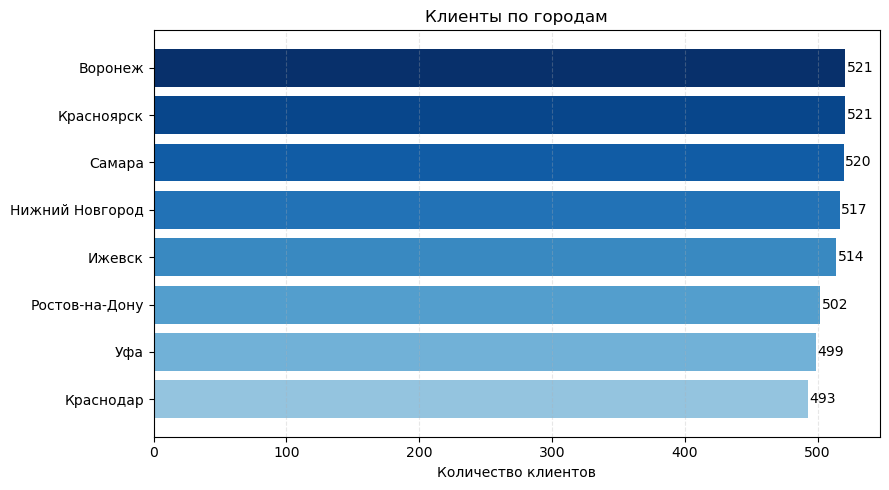

In [29]:
cityplot()

## Анализ структуры заказов 📦

Цель: проанализировать состав заказов. Для каждого заказа получить подробную статистику по товарам внутри него. Посчитать:
- суммарную стоимость всех товаров в заказе (назови столбец total_price)
- количество позиций в заказе (назови столбец items_count)
- среднюю стоимость товара в заказе (назови столбец avg_price)
- стоимость самого дорогого товара в заказе (назови столбец max_price)
- стоимость самого дешевого товара в заказе (назови столбец min_price)
  
<div class="alert alert-block alert-info">
    
<pre>
<b>SELECT</b>
  order_id,
  SUM(price) <b>AS</b> total_price,
  COUNT(*) <b>AS</b> items_count,
  AVG(price) <b>AS</b> avg_price,
  MAX(price) <b>AS</b> max_price,
  MIN(price) <b>AS</b> min_price
<b>FROM</b>
  order_items
<b>GROUP BY</b>
  order_id
<b>ORDER BY</b>
  order_id
</pre>

</div>

Результат: данные помогают оценить структуру корзины покупателей, определить диапазоны среднего чека и выявить заказы с высокой ценностью

## Своевременность доставки 🚚

Цель: понять, сколько заказов доставляется вовремя, а сколько — с опозданием. Посчитать по статусам заказов:  
1.	Общее количество заказов (total_orders).  
2.	Количество заказов, доставленных с опозданием (фактическая дата доставки order_delivered_customer_time позже ожидаемой order_estimated_delivery_time).  

<div class="alert alert-block alert-info">
    
<pre>
<b>SELECT</b>
  order_status,
  COUNT(*) <b>AS</b> total_orders,
  COUNT(order_id) <b>FILTER</b>(
    <b>WHERE</b>
      order_delivered_customer_time > order_estimated_delivery_time
  ) <b>AS</b> late_orders
<b>FROM</b>
  orders
<b>GROUP BY</b>
  order_status

</pre>

</div>

Вывод: Заказов со статусов "Delivered" - 2 535, из них 1 902 доставлены с опозданием. Таким образом, On-time Delivery составляет лишь 25%, в то время как индустриальный бенчмарк для e-commerce и маркетплейсов обычно находится в диапазоне 80–90%. Для маркетплейсов товаров для дома и красоты спрос сильно чувствителен к срокам, и задержки напрямую бьют по повторным покупкам. Для выявления первопричин необходимо провести декомпозицию задержек по следующим направлениям:
- География: регионы с максимальной долей опозданий  
- Категории товаров: возможны разные SLA и логистические цепочки  
- Логистические партнёры / склады: вклад каждого звена в задержки  
- Временной тренд: усиление или стабилизация проблемы во времени  
Без устранения причин задержек дальнейшее масштабирование маркетплейса будет ограничено качеством исполнения доставки.

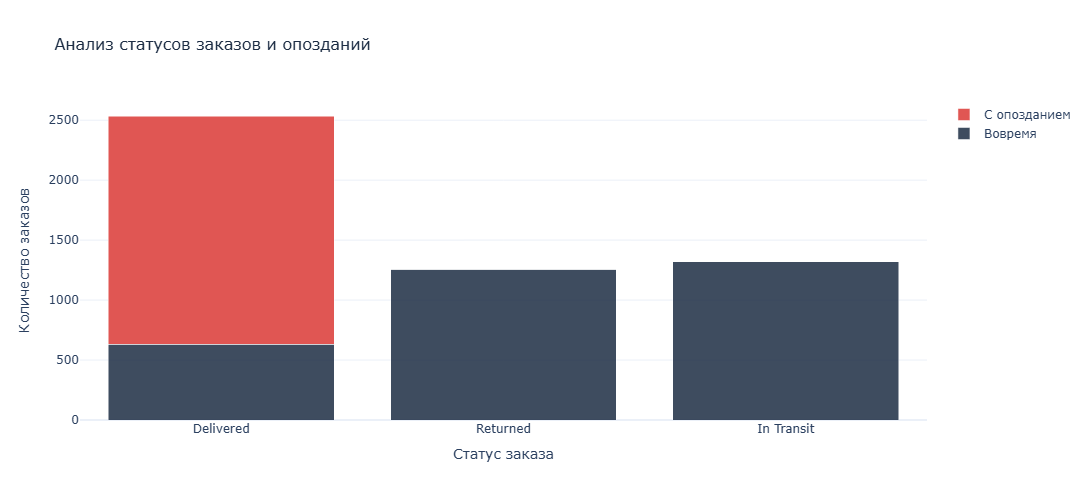

In [90]:
lateness(df)

# JOIN

## Анализ отмененных заказов по городам ❌

Цель: рассчитать долю отменённых заказов (order_status = 'Returned'). Вывести город, общее число заказов, число отмен и процент отмен.
  
<div class="alert alert-block alert-info">
    
<pre>
<b>SELECT</b>
    c.customer_city,
    COUNT(o.order_id) <b>AS</b> total_orders,
    COUNT(CASE WHEN o.order_status = 'Returned' THEN 1 END) <b>AS</b> canceled_orders,
    ROUND(COUNT(CASE WHEN o.order_status = 'Returned' THEN 1 END)::numeric / COUNT(o.order_id) *100, 2) <b>AS</b> cancel_rate_percent
<b>FROM</b> 
    customers <b>AS</b> c
<b>JOIN</b> 
    orders <b>AS</b> o <b>USING</b>(customer_id)
<b>GROUP BY</b> 
        customer_city
<b>ORDER BY</b> 
    cancel_rate_percent DESC
    
</pre>

</div>

Вывод: В топ-5 городов по доле отмененных заказов вошли Екатеринбург, Красноярск, Нижний Новгород, Самара, Тольятти. Для них требуется дополнительное исследование причин отказов. Меньше всего отмененных заказов - в Краснодаре.

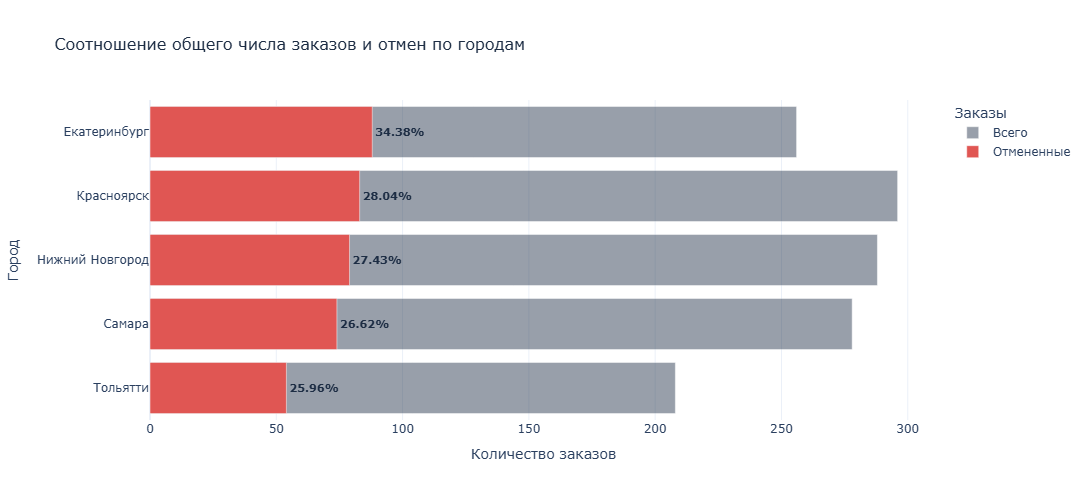

In [79]:
plot_cancel_rate_plotly(df)

## Популярность товарных категорий 🔥

Цель: определить, на какие товарные категории поступает особенно большое число заказов (больше либо равно 400). Для каждой такой категории вывести название, число уникальных товаров и число заказов
  
<div class="alert alert-block alert-info">
    
<pre>
<b>SELECT</b> 
    p.product_category_name, 
    COUNT(DISTINCT oi.product_id) <b>AS</b> products_in_category, 
    COUNT(DISTINCT oi.order_id) <b>AS</b> orders_count
<b>FROM</b> 
    products <b>AS</b> p
<b>JOIN</b> 
    order_items <b>AS</b> oi <b>USING</b>(product_id)
<b>GROUP BY</b> 
    p.product_category_name
<b>HAVING</b> 
    COUNT(oi.order_id)>400
<b>ORDER BY</b> 
    orders_count DESC

</pre>

</div>

Вывод: Категории-лидеры являются приоритетными для развития ассортимента и маркетингового продвижения: Ювелирные изделия, Детские товары, Одежда, Обувь, Здоровье и красота.

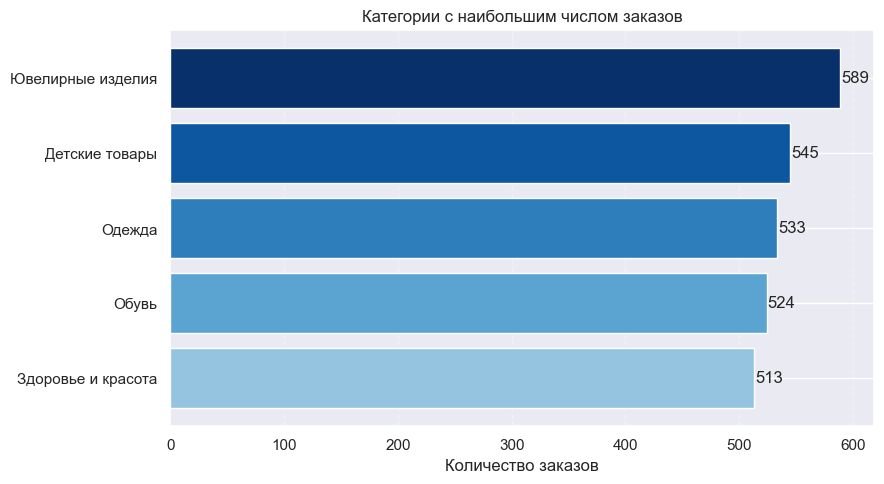

In [58]:
popular()

# Подзапросы и CTE

## Поиск премиальных брендов 👑

Цель: выявить «премиальные» бренды. Критерий такой: средняя цена товаров бренда должна быть выше общей средней цены всех товаров в магазине на 20%.
  
<div class="alert alert-block alert-info">
    
<pre>
<b>WITH</b> diff_avg_price <b>AS</b>(
    <b>SELECT</b>
        p.product_brand, 
        AVG(oi.price) <b>AS</b> brand_avg_price,
        AVG(oi.price)/(SELECT avg(price) FROM order_items) <b>AS</b> diff
    <b>FROM</b>
        products p
    <b>JOIN</b>
        order_items oi <b>USING</b>(product_id)
    <b>GROUP BY</b>
        p.product_brand
)

<b>SELECT</b>
    product_brand, 
    brand_avg_price
<b>FROM</b> 
    diff_avg_price
<b>WHERE</b> diff > 1.2
<b>ORDER BY</b> 
    brand_avg_price DESC

    
</pre>

</div>

Результат: Получен список из 6 премиальных брендов. Они формируют верхний ценовой сегмент ассортимента (24 390 – 27 265 рублей) и могут рассматриваться как ключевые драйверы маржинальности.

# Оконные функции

## Анализ динамики выручки 💸

Цель: рассчитать для каждого дня общую выручку и скользящее среднее выручки за 3 дня (текущий день и два предыдущих)
  
<div class="alert alert-block alert-info">
    
<pre>
<b>WITH</b> revenue_by_day <b>AS</b>(
    <b>SELECT</b>  
        o.order_created_time::DATE <b>AS</b> order_date,
        SUM(price) <b>AS</b> daily_revenue
    <b>FROM</b> 
        orders o
    <b>JOIN</b> order_items oi <b>USING</b>(order_id)
    <b>GROUP BY</b> 
        o.order_created_time::date
)
<b>SELECT</b> 
    order_date,
    daily_revenue,
    AVG(daily_revenue) OVER(ORDER BY order_date ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) <b>AS</b> moving_avg_3d_revenue
<b>FROM</b> 
    revenue_by_day
<b>ORDER BY</b> 
    order_date    
</pre>

</div>

Результат: В начале января сглаженная дневная выручка находилась на уровне около 66 тыс. К середине февраля она выросла до 1,85 млн, а к концу марта  превысила 5,05 млн. Маркетплейс переживает фазу взрывного роста, выручка за квартал увеличилась в сотни раз. По графику скользящей средней выручки видно, что со временем бизнес-модель стала более  устойчивой, ежедневные случайные факторы или технические сбои уже не так сильно бьют по общей картине, доходы становятся прогнозируемыми.

## Повторные покупки клиентов 🔄

Цель: рассчитать среднее время между первым и вторым заказом для всех клиентов, которые сделали больше одного заказа
  
<div class="alert alert-block alert-info">
    
<pre>
<b>WITH</b> next_order_dates <b>AS</b>(
    <b>SELECT</b>
        customer_id,
        order_created_time,
        ROW_NUMBER() OVER(PARTITION BY customer_id ORDER BY order_created_time) <b>AS</b> order_rank,
        LEAD(order_created_time, 1) OVER (PARTITION BY customer_id ORDER BY order_created_time) <b>AS</b> next_order_time
    <b>FROM</b> orders
)

<b>SELECT</b> 
    AVG(diff) AS avg_time_between_1st_and_2nd_order 
<b>FROM</b> (
    <b>SELECT</b> customer_id, 
        order_created_time,
        order_rank,
        next_order_time,
        next_order_time - order_created_time <b>AS</b> diff
    <b>FROM</b> next_order_dates
    <b>WHERE</b> order_rank=1 AND next_order_time IS NOT NULL) difference

</pre>

</div>

Вывод: В среднем новому клиенту, чтобы созреть для повторной покупки, нужно 7 дней 1 час 27 минут

## Сегментация клиентов по разнообразию покупок 👨🏻‍💼

Цель: выявить клиентов, которые покупают товары из наибольшего числа различных категорий. Посчитать для каждого клиента количество уникальных категорий, в которых он делал покупки, и присвоить ему ранг на основе этого разнообразия.
  
<div class="alert alert-block alert-info">
    
<pre>
<b>SELECT</b>
    o.customer_id, 
    COUNT(DISTINCT p.product_category_name) <b>AS</b> distinct_categories_count,
    DENSE_RANK() OVER(ORDER BY COUNT(DISTINCT p.product_category_name) DESC) <b>AS</b> diversity_rank
<b>FROM</b> 
    orders o
<b>JOIN</b> order_items oi <b>USING</b>(order_id)
<b>JOIN</b> products p <b>USING</b>(product_id)
<b>GROUP BY</b> 
    o.customer_id
<b>ORDER BY</b>
    diversity_rank, customer_id
    
</pre>

</div>

Вывод: Клиенты с большим количеством категорий являются «исследователями» и более открыты к новым предложениям, на основе текущих данных 1 ранг заняли клиенты с 11 категориями. Клиенты с небольшим количеством категорий (1-2) являются «специалистами» и могут получать персонализированные рекомендации.